<h1 style="text-align:center; font-size:38px; font-weight:680; margin-bottom:4px;">
    From Raw Records to Business Insights:
    <span style="font-size:32px; font-style:italic; font-weight:400;">
        A Python Analytics Project
    </span>
</h1>

<h1 style="text-align:center;">
Data Importing
</h1>

In [46]:
import pandas as pd
df_date=pd.read_excel("dataset.xlsx","dim_date")
df_date

,date
0,2026-03-01
1,2026-03-02
2,2026-03-03
3,2026-03-04
4,2026-03-05
...,...
56,2026-04-26
57,2026-04-27
58,2026-04-28
59,2026-04-29


In [47]:

df_customer=pd.read_excel("dataset.xlsx","dim_customer")
df_customer


,customer_id,customer_name,area,source,area_type,customer_category
0,CUST0001,kalia,gosaninuagoan,customer referral,within city,individual
1,CUST0002,deb garage,gosaninuagoan,garage referral,within city,garage
2,CUST0003,mohan,sana bazar,customer referral,within city,showroom
3,CUST0004,ram,gosaninuagoan,google search,within city,individual
4,CUST0005,banshidhar,honda showroom,garage referral,within city,showroom
...,...,...,...,...,...,...
687,CUST0688,raj kumar,bada bazar,customer referral,within city,individual
688,CUST0689,srinu,new bus-stand,owner referral,within city,individual
689,CUST0690,samar,sana bazar,customer referral,within city,individual
690,CUST0691,ujjwal,gosaninuagoan,owner referral,within city,individual


In [48]:

df_transaction=pd.read_excel("dataset.xlsx","fact_transaction")
df_transaction


,transaction_id,transaction_date,customer_id,part_name,product_name,revenue
0,TRAN0001,2026-03-01,CUST0001,visor,bike,200
1,TRAN0002,2026-03-01,CUST0002,back panel,bike,150
2,TRAN0003,2026-03-01,CUST0002,back panel,bike,100
3,TRAN0004,2026-03-01,CUST0003,visor,bike,200
4,TRAN0005,2026-03-01,CUST0004,bumper,car,850
...,...,...,...,...,...,...
821,TRAN0822,2026-04-30,CUST0688,back panel,bike,200
822,TRAN0823,2026-04-30,CUST0689,visor,bike,300
823,TRAN0824,2026-04-30,CUST0690,pesticide tank,pesticide sprayer machine,600
824,TRAN0825,2026-04-30,CUST0691,mudguard,bike,150


In [49]:

df_expense=pd.read_excel("dataset.xlsx","fact_expense")
df_expense


,date,expense_type,quantity,expense
0,2026-03-01,resin,200ml,50
1,2026-03-01,chalk-powder,250ml,4
2,2026-03-01,catalyst,6.7ml,3.35
3,2026-03-01,mat,30g,9
4,2026-03-01,transportation,rs.200/3days,66.7
...,...,...,...,...
605,2026-04-30,worker,-,-
606,2026-04-30,rent,rs.2500/30days,83.33
607,2026-04-30,refreshment,20L water,30
608,2026-04-30,electricity,rs.200/30,6.66


<h1 style="text-align:center;">
Data Exploration & Data Cleaning
</h1>

In [50]:

df_date.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    61 non-null     datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 620.0 bytes


In [51]:

df_customer.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692 entries, 0 to 691
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        692 non-null    object
 1   customer_name      692 non-null    object
 2   area               692 non-null    object
 3   source             692 non-null    object
 4   area_type          692 non-null    object
 5   customer_category  692 non-null    object
dtypes: object(6)
memory usage: 32.6+ KB


In [52]:

df_transaction.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 826 entries, 0 to 825
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    826 non-null    object        
 1   transaction_date  826 non-null    datetime64[ns]
 2   customer_id       826 non-null    object        
 3   part_name         826 non-null    object        
 4   product_name      826 non-null    object        
 5   revenue           826 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 38.8+ KB


In [53]:

df_transaction.revenue.describe().round()


count     826.0
mean      268.0
std       200.0
min        50.0
25%       150.0
50%       200.0
75%       300.0
max      1350.0
Name: revenue, dtype: float64

In [54]:

df_expense.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          610 non-null    datetime64[ns]
 1   expense_type  610 non-null    object        
 2   quantity      610 non-null    object        
 3   expense       587 non-null    object        
dtypes: datetime64[ns](1), object(3)
memory usage: 19.2+ KB


In [55]:


df_expense["expense"] =pd.to_numeric(df_expense["expense"],errors="coerce")
df_expense.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          610 non-null    datetime64[ns]
 1   expense_type  610 non-null    object        
 2   quantity      610 non-null    object        
 3   expense       558 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 19.2+ KB


<h1 style="text-align:center;">
Data Transformation
</h1>

In [56]:
df_date["week_num"] =df_date["date"].dt.isocalendar().week
df_date["week_no"] = "wk-" + df_date["week_num"].astype(str)
df_date=df_date[["date","week_no"]]
df_date


,date,week_no
0,2026-03-01,wk-9
1,2026-03-02,wk-10
2,2026-03-03,wk-10
3,2026-03-04,wk-10
4,2026-03-05,wk-10
...,...,...
56,2026-04-26,wk-17
57,2026-04-27,wk-18
58,2026-04-28,wk-18
59,2026-04-29,wk-18


In [57]:

df_date["month_name"] = df_date["date"].dt.month_name()
df_date


,date,week_no,month_name
0,2026-03-01,wk-9,March
1,2026-03-02,wk-10,March
2,2026-03-03,wk-10,March
3,2026-03-04,wk-10,March
4,2026-03-05,wk-10,March
...,...,...,...
56,2026-04-26,wk-17,April
57,2026-04-27,wk-18,April
58,2026-04-28,wk-18,April
59,2026-04-29,wk-18,April


In [58]:

df_sale=pd.merge(df_transaction,df_customer,on="customer_id")
df_sale.head(4)


,transaction_id,transaction_date,customer_id,part_name,product_name,revenue,customer_name,area,source,area_type,customer_category
0,TRAN0001,2026-03-01,CUST0001,visor,bike,200,kalia,gosaninuagoan,customer referral,within city,individual
1,TRAN0002,2026-03-01,CUST0002,back panel,bike,150,deb garage,gosaninuagoan,garage referral,within city,garage
2,TRAN0003,2026-03-01,CUST0002,back panel,bike,100,deb garage,gosaninuagoan,garage referral,within city,garage
3,TRAN0004,2026-03-01,CUST0003,visor,bike,200,mohan,sana bazar,customer referral,within city,showroom


In [59]:

df_final=pd.merge(df_sale,df_date,left_on="transaction_date",right_on="date").drop(columns="date")
df_sale.head(4)


,transaction_id,transaction_date,customer_id,part_name,product_name,revenue,customer_name,area,source,area_type,customer_category
0,TRAN0001,2026-03-01,CUST0001,visor,bike,200,kalia,gosaninuagoan,customer referral,within city,individual
1,TRAN0002,2026-03-01,CUST0002,back panel,bike,150,deb garage,gosaninuagoan,garage referral,within city,garage
2,TRAN0003,2026-03-01,CUST0002,back panel,bike,100,deb garage,gosaninuagoan,garage referral,within city,garage
3,TRAN0004,2026-03-01,CUST0003,visor,bike,200,mohan,sana bazar,customer referral,within city,showroom


In [60]:
daily_revenue=df_final.groupby("transaction_date")["revenue"].sum().reset_index()
daily_revenue.rename(columns={"transaction_date":"date"}, inplace=True)
daily_revenue

,date,revenue
0,2026-03-01,4450
1,2026-03-02,2900
2,2026-03-03,4430
3,2026-03-04,3550
4,2026-03-05,3250
...,...,...
56,2026-04-26,2530
57,2026-04-27,4030
58,2026-04-28,2700
59,2026-04-29,3020


In [61]:

daily_expense=df_expense.groupby("date")["expense"].sum().round().reset_index()
daily_expense


,date,expense
0,2026-03-01,455.0
1,2026-03-02,189.0
2,2026-03-03,425.0
3,2026-03-04,455.0
4,2026-03-05,407.0
...,...,...
56,2026-04-26,208.0
57,2026-04-27,458.0
58,2026-04-28,208.0
59,2026-04-29,410.0


In [62]:

daily_analysis=pd.merge(daily_revenue,daily_expense,on="date")
daily_analysis


,date,revenue,expense
0,2026-03-01,4450,455.0
1,2026-03-02,2900,189.0
2,2026-03-03,4430,425.0
3,2026-03-04,3550,455.0
4,2026-03-05,3250,407.0
...,...,...,...
56,2026-04-26,2530,208.0
57,2026-04-27,4030,458.0
58,2026-04-28,2700,208.0
59,2026-04-29,3020,410.0


In [63]:

daily_analysis["profit"]=daily_analysis["revenue"]-daily_analysis["expense"]
daily_analysis


,date,revenue,expense,profit
0,2026-03-01,4450,455.0,3995.0
1,2026-03-02,2900,189.0,2711.0
2,2026-03-03,4430,425.0,4005.0
3,2026-03-04,3550,455.0,3095.0
4,2026-03-05,3250,407.0,2843.0
...,...,...,...,...
56,2026-04-26,2530,208.0,2322.0
57,2026-04-27,4030,458.0,3572.0
58,2026-04-28,2700,208.0,2492.0
59,2026-04-29,3020,410.0,2610.0


In [82]:

daily_analysis["profit%"]=((daily_analysis["profit"]/daily_analysis["revenue"])*100).round(0)
daily_analysis["week_no"]=df_date["date"].dt.isocalendar().week
daily_analysis


,date,revenue,expense,profit,profit%,week_no
0,2026-03-01,4450,455.0,3995.0,90.0,9
1,2026-03-02,2900,189.0,2711.0,93.0,10
2,2026-03-03,4430,425.0,4005.0,90.0,10
3,2026-03-04,3550,455.0,3095.0,87.0,10
4,2026-03-05,3250,407.0,2843.0,87.0,10
...,...,...,...,...,...,...
56,2026-04-26,2530,208.0,2322.0,92.0,17
57,2026-04-27,4030,458.0,3572.0,89.0,18
58,2026-04-28,2700,208.0,2492.0,92.0,18
59,2026-04-29,3020,410.0,2610.0,86.0,18


In [65]:
daily_analysis1 = pd.merge(
    daily_analysis,
    df_date,
    on="date",
    how="left"
)[["date", "week_no", "month_name", "revenue", "expense", "profit","profit%"]]

daily_analysis1.head(7)

,date,week_no,month_name,revenue,expense,profit,profit%
0,2026-03-01,wk-9,March,4450,455.0,3995.0,90.0
1,2026-03-02,wk-10,March,2900,189.0,2711.0,93.0
2,2026-03-03,wk-10,March,4430,425.0,4005.0,90.0
3,2026-03-04,wk-10,March,3550,455.0,3095.0,87.0
4,2026-03-05,wk-10,March,3250,407.0,2843.0,87.0
5,2026-03-06,wk-10,March,3020,992.0,2028.0,67.0
6,2026-03-07,wk-10,March,2300,419.0,1881.0,82.0


In [66]:

weekly_analysis=daily_analysis1 .groupby("week_no",sort=False)["revenue"].sum().reset_index()
weekly_analysis


,week_no,revenue
0,wk-9,4450
1,wk-10,22940
2,wk-11,25380
3,wk-12,27880
4,wk-13,24890
5,wk-14,27355
6,wk-15,26580
7,wk-16,24345
8,wk-17,25100
9,wk-18,12220


In [67]:

weekly_analysis["expense"]=daily_analysis1 .groupby("week_no")["expense"].sum().reset_index()["expense"]
weekly_analysis


,week_no,revenue,expense
0,wk-9,4450,3414.0
1,wk-10,22940,3077.0
2,wk-11,25380,3294.0
3,wk-12,27880,2998.0
4,wk-13,24890,2858.0
5,wk-14,27355,1678.0
6,wk-15,26580,2966.0
7,wk-16,24345,2616.0
8,wk-17,25100,1314.0
9,wk-18,12220,455.0


In [68]:

weekly_analysis["profit"]=weekly_analysis["revenue"]-weekly_analysis["expense"]
weekly_analysis


,week_no,revenue,expense,profit
0,wk-9,4450,3414.0,1036.0
1,wk-10,22940,3077.0,19863.0
2,wk-11,25380,3294.0,22086.0
3,wk-12,27880,2998.0,24882.0
4,wk-13,24890,2858.0,22032.0
5,wk-14,27355,1678.0,25677.0
6,wk-15,26580,2966.0,23614.0
7,wk-16,24345,2616.0,21729.0
8,wk-17,25100,1314.0,23786.0
9,wk-18,12220,455.0,11765.0


In [69]:

weekly_analysis["profit%"]=((weekly_analysis["profit"]/weekly_analysis["revenue"])*100).round(0)
weekly_analysis


,week_no,revenue,expense,profit,profit%
0,wk-9,4450,3414.0,1036.0,23.0
1,wk-10,22940,3077.0,19863.0,87.0
2,wk-11,25380,3294.0,22086.0,87.0
3,wk-12,27880,2998.0,24882.0,89.0
4,wk-13,24890,2858.0,22032.0,89.0
5,wk-14,27355,1678.0,25677.0,94.0
6,wk-15,26580,2966.0,23614.0,89.0
7,wk-16,24345,2616.0,21729.0,89.0
8,wk-17,25100,1314.0,23786.0,95.0
9,wk-18,12220,455.0,11765.0,96.0


<h1 style="text-align:center;">
Exploratory Data Analysis (EDA)
</h1>

**1) How are revenue, expenses, and profit trending across weeks.**

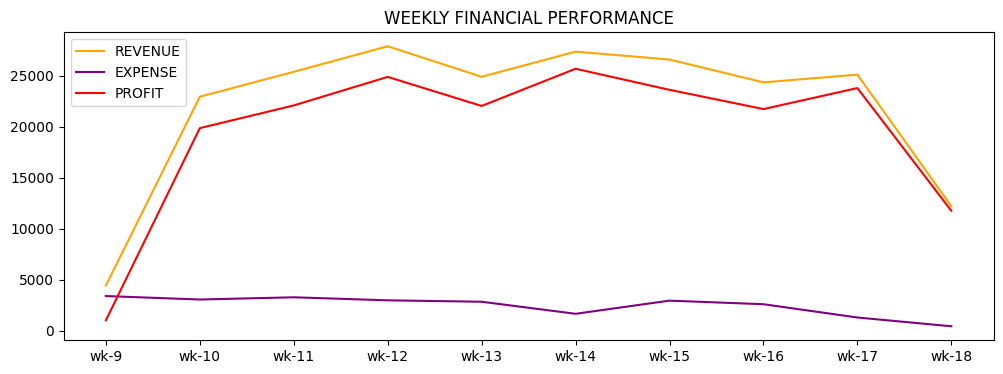

In [70]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(weekly_analysis["week_no"],weekly_analysis["revenue"],color="orange",label="REVENUE")
plt.plot(weekly_analysis["week_no"],weekly_analysis["expense"],color="purple",label="EXPENSE")
plt.plot(weekly_analysis["week_no"],weekly_analysis["profit"],color="red",label="PROFIT")
plt.title("WEEKLY FINANCIAL PERFORMANCE")
plt.legend()
plt.show()



**2) Which expense categories contribute the most to overall business expenses?**

In [71]:
df_expense.groupby("expense_type").expense.sum().round(0).sort_values(ascending=False)

expense_type
worker            10400.0
rent               5000.0
transportation     4002.0
resin              2875.0
refreshment         730.0
mat                 478.0
electricity         400.0
wastage             361.0
chalk-powder        237.0
catalyst            187.0
Name: expense, dtype: float64

**3) How has the profit percentage changed across different weeks?**

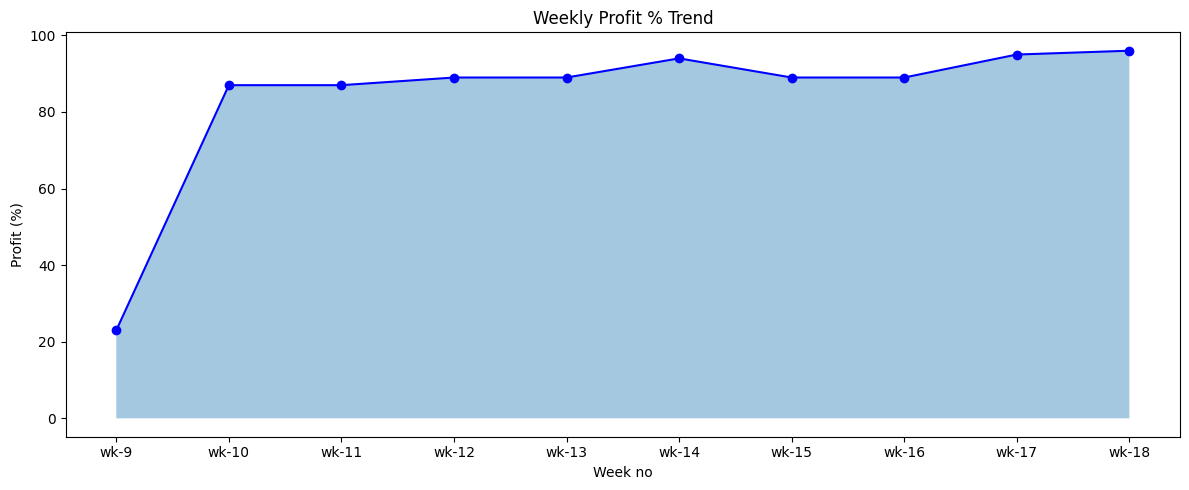

In [72]:
plt.figure(figsize=(12,5))

plt.fill_between(
    weekly_analysis["week_no"],
    weekly_analysis["profit%"],
    alpha=0.4
)

plt.plot(
    weekly_analysis["week_no"],
    weekly_analysis["profit%"],
    marker="o",
    color="blue"
)


plt.title("Weekly Profit % Trend")
plt.xlabel("Week no")
plt.ylabel("Profit (%)")


plt.tight_layout()
plt.show()

**4) What is the relationship between revenue and profit across different weeks?**

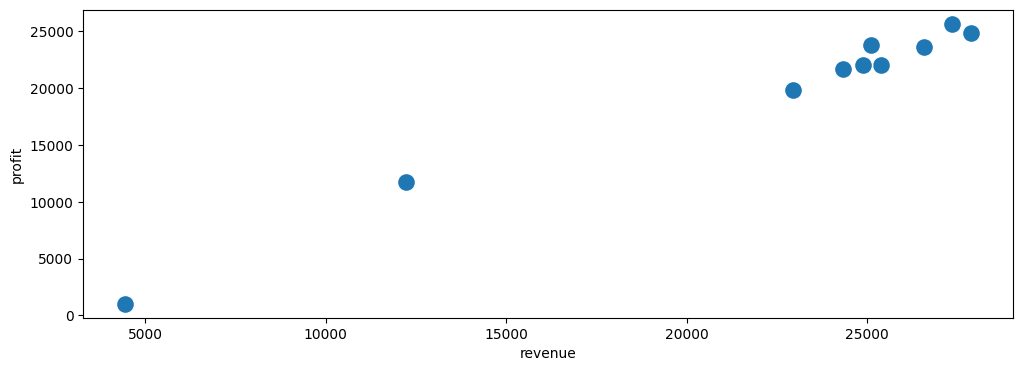

In [73]:
import seaborn as sns
plt.figure(figsize=(12,4))
sns.scatterplot(data=weekly_analysis,x="revenue",y="profit",s=170)
plt.show()


**5) Which source brings the most customers?**

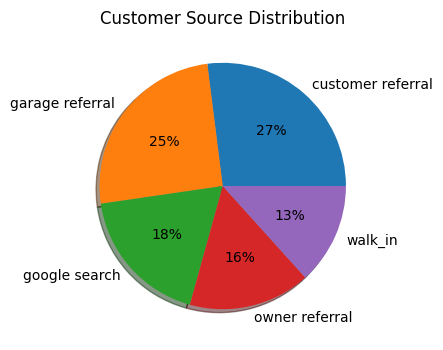

In [74]:
source=df_final.source.value_counts()
total_source=source[["customer referral","garage referral","google search","owner referral","walk_in"]]

plt.figure(figsize=(12,4))
plt.pie(total_source,labels=total_source.index,autopct="%.0f%%",shadow=True)
plt.title("Customer Source Distribution")
plt.show()

**6) What percentage of customer return?**

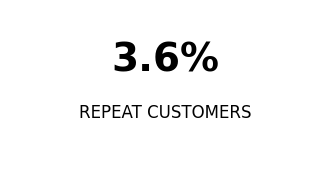

In [75]:
total_customers = df_final["customer_id"].nunique()

repeat_customers = (
    df_final.groupby("customer_id")
            .size()
            .gt(1)
            .sum()
)

repeat_customer_pct = (repeat_customers / total_customers) * 100


fig, ax = plt.subplots(figsize=(4,2))

ax.text(0.5, 0.6,
        f"{repeat_customer_pct:.1f}%",
        fontsize=28,
        fontweight="bold",
        ha="center")

ax.text(0.5, 0.3,
        "REPEAT CUSTOMERS",
        fontsize=12,
        ha="center")

ax.axis("off")
plt.show()

**7) Who are our top 10 valuable and loyal customers?**

In [85]:
customer_summary = (
    df_final.groupby(["customer_name","customer_category"])
            .agg(
                total_revenue=("revenue", "sum"),
                visit_count=("customer_name", "count")
               )
            .sort_values(
                by=["total_revenue" ,"visit_count"],
                ascending=False
            )
            .reset_index()
)

customer_summary.head(10)


,customer_name,customer_category,total_revenue,visit_count
0,maheswara garage,garage,5040,18
1,the ali garage,garage,3570,9
2,maharan garage,garage,3070,9
3,manoj garage,garage,2720,6
4,sobit raj garage,garage,2640,8
5,kiran garage,garage,2500,8
6,tilochana garage,garage,2390,14
7,raghav,showroom,2190,5
8,yuvraj,showroom,2090,10
9,mohan,showroom,1990,7


**8) What is the distribution of customers across different customer categories**

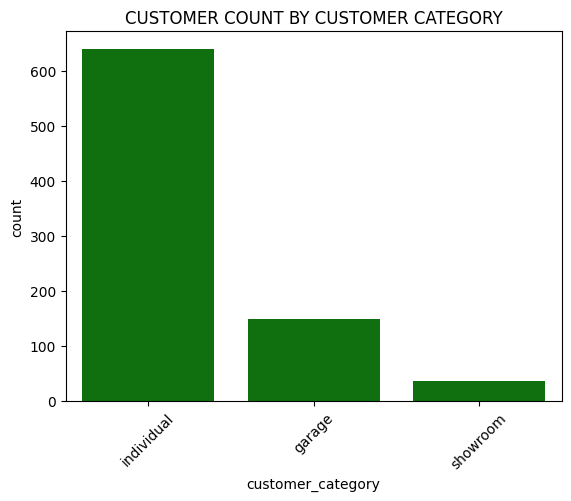

In [77]:
import seaborn as sns
sns.countplot(data=df_final, x="customer_category",color="green")

plt.title("CUSTOMER COUNT BY CUSTOMER CATEGORY")
plt.xticks(rotation=45)
plt.show()

**9) What proportion of revenue comes from within-city versus outside-city customers?**

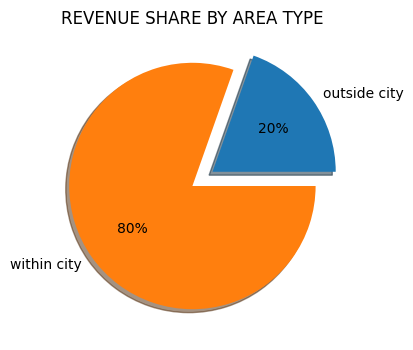

In [78]:
total_area_type=df_final.groupby("area_type").revenue.sum()
plt.figure(figsize=(12,4))
plt.pie(total_area_type,labels=total_area_type.index,autopct="%.0f%%",shadow=True,explode=(0.2,0))

plt.title("REVENUE SHARE BY AREA TYPE")
plt.xticks(rotation=45)
plt.show()

**10. What are the top 7 revenue-generating areas?**

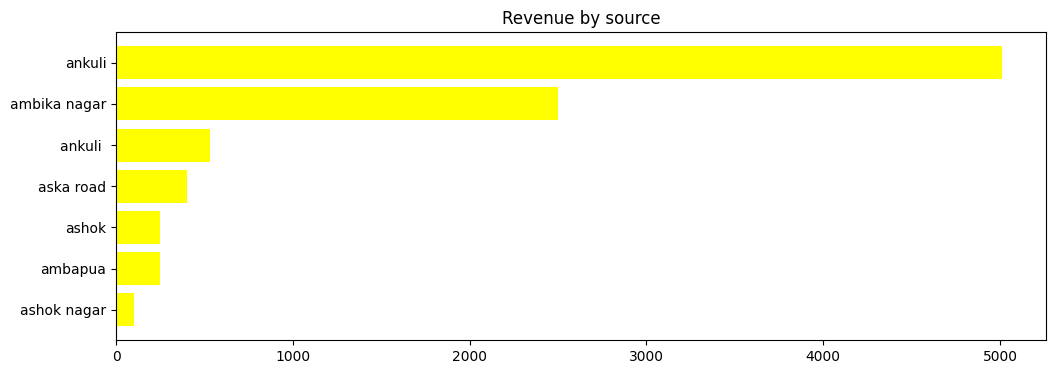

In [79]:
top_7_area=df_final.groupby("area").revenue.sum().head(7).sort_values(ascending=True)
plt.figure(figsize=(12,4))
plt.barh(top_7_area.index,top_7_area.values,color="yellow")
plt.title("Revenue by source")
plt.show()

**11) What is the top 7 frequently repaired parts**

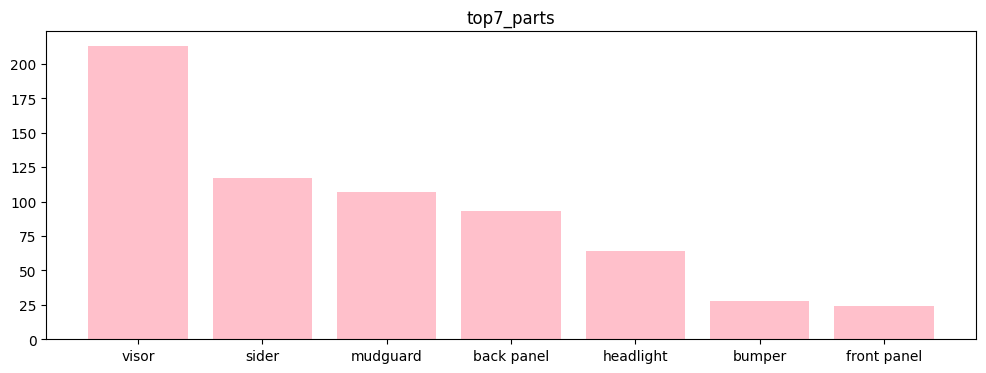

In [80]:
top7_parts=(
            df_final.part_name.value_counts().head(7)
)
plt.figure(figsize=(12,4))
plt.bar(top7_parts.index, top7_parts.values,color="pink")
plt.title("top7_parts")
plt.show()

**12) What is the revenue distribution across different parts?**

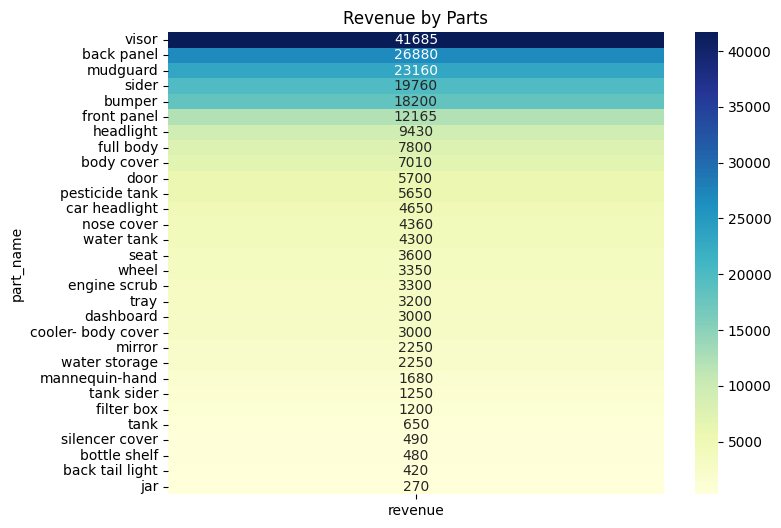

In [81]:
part_revenue = (
    df_final.groupby("part_name")["revenue"].sum()
            .sort_values(ascending=False)
            .to_frame()
)
plt.figure(figsize=(8,6))
sns.heatmap(
    part_revenue,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Revenue by Parts")
plt.show()